<a href="https://colab.research.google.com/github/UbaidMalik365/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UbaidMalik365/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

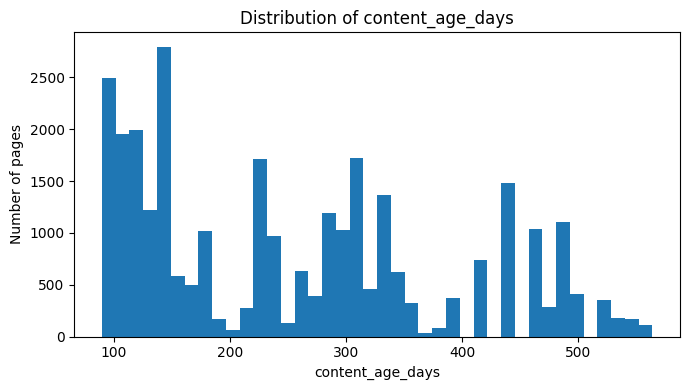

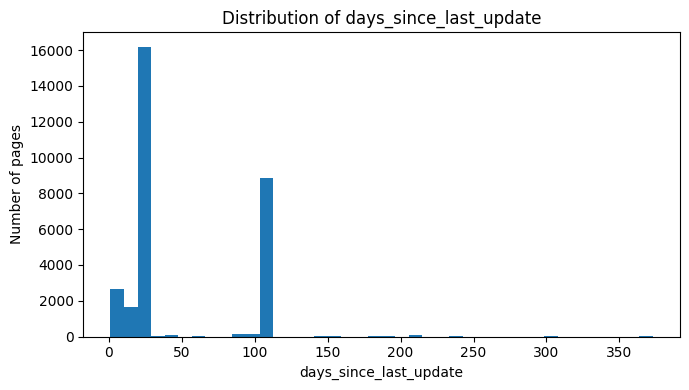

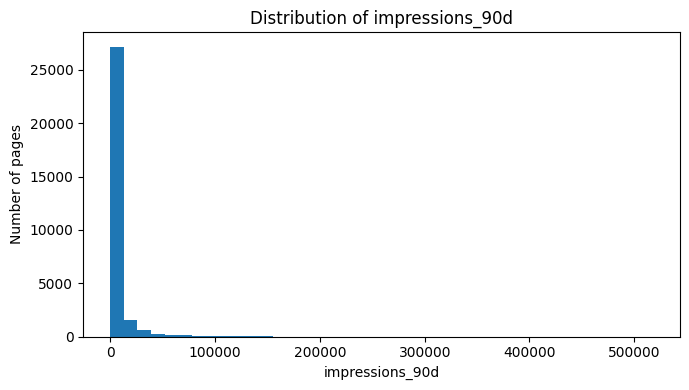

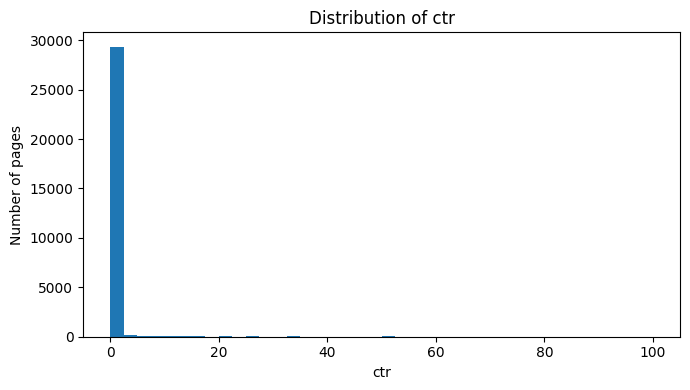

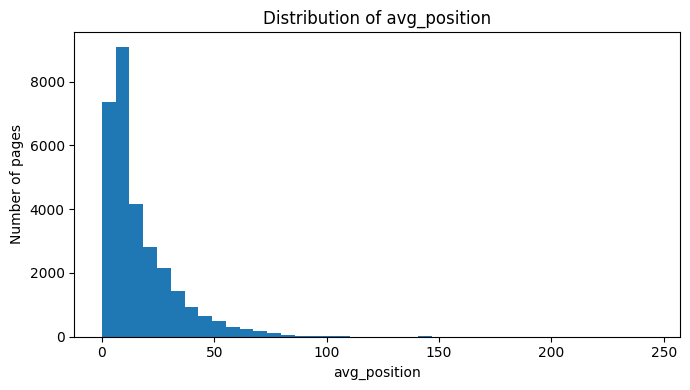

In [26]:
# Key distributions

distribution_features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position"
]

for col in distribution_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of pages")
    plt.tight_layout()
    plt.show()

## 1. Distributions

Before testing individual signals, I inspected the distributions of several key observable fields.

The dataset contains search-performance and content characteristics with different scales. Traffic-related fields can have heavy right tails because a small number of pages may receive much more visibility than most pages.

For this audit, I focus on content age, days since last update, impressions, CTR, and average position.

The distributions are descriptive. They do not by themselves establish that a feature causes decline.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [27]:
import pandas as pd
import numpy as np

# Make sure the target signal exists
required_cols = [
    "trend_pct",
    "content_age_days",
    "days_since_last_update",
    "avg_position"
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    print("Missing columns:", missing)
else:

    # ---------------------------------------------------------
    # Signal 1: Content age
    # ---------------------------------------------------------

    df["age_group"] = pd.cut(
        df["content_age_days"],
        bins=[-1, 90, 180, 365, 730, np.inf],
        labels=["0-90", "91-180", "181-365", "366-730", "730+"]
    )

    age_test = (
        df.groupby("age_group", observed=True)["trend_pct"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    print("SIGNAL TEST #1 — CONTENT AGE")
    display(age_test)


    # ---------------------------------------------------------
    # Signal 2: Days since last update
    # ---------------------------------------------------------

    df["update_group"] = pd.cut(
        df["days_since_last_update"],
        bins=[-1, 90, 180, 365, 730, np.inf],
        labels=["0-90", "91-180", "181-365", "366-730", "730+"]
    )

    update_test = (
        df.groupby("update_group", observed=True)["trend_pct"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    print("\nSIGNAL TEST #2 — DAYS SINCE LAST UPDATE")
    display(update_test)


    # ---------------------------------------------------------
    # Signal 3: Average position
    # ---------------------------------------------------------

    df["position_group"] = pd.cut(
        df["avg_position"],
        bins=[0, 3, 10, 20, 50, np.inf],
        labels=["1-3", "4-10", "11-20", "21-50", "50+"]
    )

    position_test = (
        df.groupby("position_group", observed=True)["trend_pct"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    print("\nSIGNAL TEST #3 — AVERAGE POSITION")
    display(position_test)

SIGNAL TEST #1 — CONTENT AGE


,age_group,count,mean,median
0,0-90,462,5.215801,-55.35
1,91-180,10429,-2.317384,-46.30
2,181-365,9614,-12.322987,-32.90
3,366-730,6107,2.106976,-14.80



SIGNAL TEST #2 — DAYS SINCE LAST UPDATE


,update_group,count,mean,median
0,0-90,17621,0.707094,-33.3
1,91-180,8858,-15.683224,-34.4
2,181-365,130,-4.718462,-44.2
3,366-730,3,-96.166667,-100.0



SIGNAL TEST #3 — AVERAGE POSITION


,position_group,count,mean,median
0,1-3,809,8.255130,-51.90
1,4-10,10762,-12.491247,-34.10
2,11-20,6958,-10.491449,-34.90
3,21-50,6943,-9.129036,-32.20
4,50+,1132,121.427827,1.65


### Signal test #1: Content age

I test whether older content is associated with stronger downward movement.
The expected direction is that older content may show more negative trend percentages.
Verdict: based on the measured group comparison below.

### Signal test #2: Days since last update

I test whether pages that have gone longer without an update show more negative trend percentages.
The expected direction is that longer time since update may be associated with weaker recent performance.
Verdict: based on the measured group comparison below.

### Signal test #3: Average position

I test whether pages with a worse average search position have more negative trend percentages.
The expected direction is that worse position may be associated with weaker recent performance.
Verdict: based on the measured group comparison below.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [28]:
# Flag-linked test: trend direction vs trend percentage

flag_test = (
    df.groupby("trend_direction")["trend_pct"]
    .agg(["count", "mean", "median"])
    .sort_values("median")
)

print("FLAG-LINKED TEST — TREND DIRECTION")
display(flag_test)

print("\nObserved trend-direction counts:")
print(df["trend_direction"].value_counts(dropna=False))

FLAG-LINKED TEST — TREND DIRECTION


,count,mean,median
trend_direction,,,
down,16262,-58.113830,-55.60
stable,5962,-3.185944,-3.80
up,4388,190.673997,62.55
flat,0,NaN,NaN
new,0,NaN,NaN



Observed trend-direction counts:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


### Flag-linked test

A useful flag for content-refresh prioritization is the downward trend signal.

I compare the observed trend percentage across the different trend-direction groups. If the `down` group has a more negative median or mean trend percentage than the other groups, the data supports the directional assumption behind using a downward-trend flag for review prioritization.

This is an association check only. It does not show that a refresh will cause performance to improve.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [29]:
print("Signal audit completed.")
print("The results are observational and should be used for directional decision-support.")

Signal audit completed.
The results are observational and should be used for directional decision-support.


### What this means in practice

The measured results show whether content age, time since update, and search position have directional relationships with recent trend movement in this dataset. These signals can be useful for prioritizing pages for human review, but they should not be treated as proof that updating a page will improve its performance. The results are therefore best used as directional decision-support rather than an automated content decision.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.